# Training Data vs Eval Data Comparison
**COMP 432 — Adaptive LOD Control**

Loads `training_data_labeled.csv` and the latest `eval_neural_*.csv`
and produces diagnostic plots comparing the two distributions.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import glob

print('Imports OK')

Imports OK


## 1. Configuration — edit paths here

In [34]:
# paths relative to this notebook location (ml_pipeline/notebooks/ or ml_pipeline/)
BASE_DIR = Path('../..').resolve()
TRAIN_PATH       =  BASE_DIR / 'data' / 'Train_Merged_labeled'/ 'training_data_labeled.csv'
EVAL_DIR       =  BASE_DIR / 'data' / 'Stage_1_Eval'
PLOTS_DIR = BASE_DIR / 'plots' / 'Stage_1' / 'Eval'

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'BASE_DIR:    {BASE_DIR}')
print(f'EVAL_DIR:    {EVAL_DIR}')
print(f'PLOTS_DIR:    {PLOTS_DIR}')
print(f'TRAIN_PATH:    {TRAIN_PATH}')


TARGET_FRAME_MS = 16.666
SAFE_TARGET_MS  = 16.666

TC = '#4C72B0'  # train color
EC = '#DD8452'  # eval color

# auto-detect latest eval CSV
eval_files = sorted(glob.glob(str(EVAL_DIR / 'eval_neural_*.csv')))
if not eval_files:
    raise FileNotFoundError(f'No eval_neural_*.csv found in {EVAL_DIR}')
EVAL_PATH = eval_files[-1]

print(f'Train : {TRAIN_PATH}')
print(f'Eval  : {EVAL_PATH}')

BASE_DIR:    C:\Users\Gica\neural-lod\ml_pipeline
EVAL_DIR:    C:\Users\Gica\neural-lod\ml_pipeline\data\Stage_1_Eval
PLOTS_DIR:    C:\Users\Gica\neural-lod\ml_pipeline\plots\Stage_1\Eval
TRAIN_PATH:    C:\Users\Gica\neural-lod\ml_pipeline\data\Train_Merged_labeled\training_data_labeled.csv
Train : C:\Users\Gica\neural-lod\ml_pipeline\data\Train_Merged_labeled\training_data_labeled.csv
Eval  : C:\Users\Gica\neural-lod\ml_pipeline\data\Stage_1_Eval\eval_neural_20260324_215722.csv


## 2. Load Data

In [35]:
train = pd.read_csv(TRAIN_PATH)
eval_ = pd.read_csv(EVAL_PATH, comment='#')

# synthesize elapsed_s if missing
if 'elapsed_s' in eval_.columns:
    eval_ = eval_[~eval_['elapsed_s'].astype(str).str.startswith('#')]
    eval_['elapsed_s'] = pd.to_numeric(eval_['elapsed_s'], errors='coerce')
    eval_ = eval_.dropna(subset=['elapsed_s'])
else:
    eval_['elapsed_s'] = np.arange(len(eval_)) / 60.0

# normalize column names
train = train.rename(columns={
    'cpu_frame_time_ms': 'cpu_ms',
    'gpu_frame_time_ms': 'gpu_ms',
    'target_lod_bias':   'lod_bias',
})
eval_ = eval_.rename(columns={
    'cpu_frame_ms':      'cpu_ms',
    'gpu_frame_ms':      'gpu_ms',
    'cpu_frame_time_ms': 'cpu_ms',
    'gpu_frame_time_ms': 'gpu_ms',
    'lod_bias_current':  'lod_bias',
})

train['over_budget'] = train['cpu_ms'] > TARGET_FRAME_MS
eval_['over_budget'] = eval_['cpu_ms']  > TARGET_FRAME_MS

print(f'Train rows : {len(train)}')
print(f'Eval rows  : {len(eval_)}')
print(f'Train cols : {list(train.columns)}')
print(f'Eval cols  : {list(eval_.columns)}')

Train rows : 60000
Eval rows  : 5000
Train cols : ['cpu_ms', 'gpu_ms', 'triangle_count', 'camera_velocity', 'visible_renderer_count', 'lod_bias_current', 'fps', 'camera_angular_velocity', 'draw_call_estimate', 'previous_bias', 'frame_headroom_ms', 'cam_pos_x', 'cam_pos_y', 'cam_pos_z', 'cam_rot_y', 'screen_coverage', 'move_speed', 'rotate_speed', 'waypoint_index', 'path_progress', 'draw_calls', 'batches_count', 'setpass_calls', 'source_file', 'lod_bias', 'over_budget']
Eval cols  : ['cpu_ms', 'gpu_ms', 'triangle_count', 'camera_velocity', 'visible_renderer_count', 'lod_bias', 'fps', 'camera_angular_velocity', 'draw_call_estimate', 'previous_bias', 'frame_headroom_ms', 'cam_pos_x', 'cam_pos_y', 'cam_pos_z', 'cam_rot_y', 'screen_coverage', 'move_speed', 'rotate_speed', 'waypoint_index', 'path_progress', 'draw_calls', 'batches_count', 'setpass_calls', 'target_lod_bias', 'elapsed_s', 'over_budget']


## 3. Summary Statistics

In [36]:
def print_stats(df, label):
    cpu = df['cpu_ms']
    print(f"\n{'='*45}")
    print(f'  {label}')
    print(f"{'='*45}")
    print(f'  Rows         : {len(df)}')
    print(f'  CPU mean     : {cpu.mean():.2f} ms')
    print(f'  CPU median   : {cpu.median():.2f} ms')
    print(f'  CPU P95      : {cpu.quantile(0.95):.2f} ms')
    print(f'  CPU P99      : {cpu.quantile(0.99):.2f} ms')
    print(f'  CPU max      : {cpu.max():.2f} ms')
    print(f'  Over budget  : {df["over_budget"].mean()*100:.1f}%')
    print(f'  LOD bias mean: {df["lod_bias"].mean():.4f}')
    print(f'  LOD bias std : {df["lod_bias"].std():.4f}')
    print(f'  LOD bias min : {df["lod_bias"].min():.4f}')
    print(f'  LOD bias max : {df["lod_bias"].max():.4f}')
    if 'gpu_ms' in df.columns:
        gpu = df['gpu_ms']
        print(f'  GPU mean     : {gpu.mean():.2f} ms')
        print(f'  GPU P95      : {gpu.quantile(0.95):.2f} ms')

print_stats(train, 'TRAINING DATA')
print_stats(eval_,  'EVAL / INFERENCE')

if 'bias_switched' in eval_.columns:
    print(f'\n  Bias switch rate : {eval_["bias_switched"].mean()*100:.2f}% of frames')

# percentile comparison table
print(f"\n{'Percentile':<12} {'Train CPU':>12} {'Eval CPU':>12} {'Delta':>10}")
print('-' * 48)
for p in [50, 75, 90, 95, 99]:
    t = train['cpu_ms'].quantile(p/100)
    e = eval_['cpu_ms'].quantile(p/100)
    print(f"  P{p:<9} {t:>12.2f} {e:>12.2f} {e-t:>+10.2f}")


  TRAINING DATA
  Rows         : 60000
  CPU mean     : 17.24 ms
  CPU median   : 16.67 ms
  CPU P95      : 25.80 ms
  CPU P99      : 35.41 ms
  CPU max      : 46.05 ms
  Over budget  : 55.2%
  LOD bias mean: 1.0673
  LOD bias std : 0.6435
  LOD bias min : 0.2500
  LOD bias max : 2.0000
  GPU mean     : 4.40 ms
  GPU P95      : 5.26 ms

  EVAL / INFERENCE
  Rows         : 5000
  CPU mean     : 20.84 ms
  CPU median   : 16.59 ms
  CPU P95      : 38.43 ms
  CPU P99      : 68.85 ms
  CPU max      : 2323.70 ms
  Over budget  : 47.5%
  LOD bias mean: 0.6836
  LOD bias std : 0.6557
  LOD bias min : 0.2500
  LOD bias max : 2.0000
  GPU mean     : 5.00 ms
  GPU P95      : 6.73 ms

Percentile      Train CPU     Eval CPU      Delta
------------------------------------------------
  P50               16.67        16.59      -0.09
  P75               16.73        27.97     +11.24
  P90               19.88        36.85     +16.96
  P95               25.80        38.43     +12.63
  P99             

## 4. LOD Bias Distribution

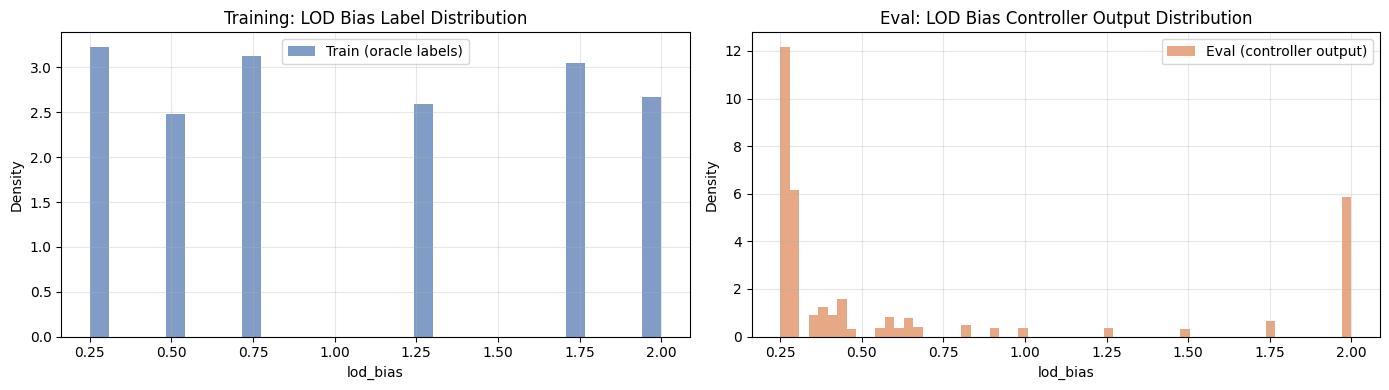

Saved compare_bias_distribution.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train['lod_bias'], bins=30, alpha=0.7, color=TC, label='Train (oracle labels)', density=True)
axes[0].set_title('Training: LOD Bias Label Distribution')
axes[0].set_xlabel('lod_bias')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(eval_['lod_bias'], bins=60, alpha=0.7, color=EC, label='Eval (controller output)', density=True)
axes[1].set_title('Eval: LOD Bias Controller Output Distribution')
axes[1].set_xlabel('lod_bias')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'compare_bias_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved compare_bias_distribution.png')

## 5. CPU Frame Time Distribution

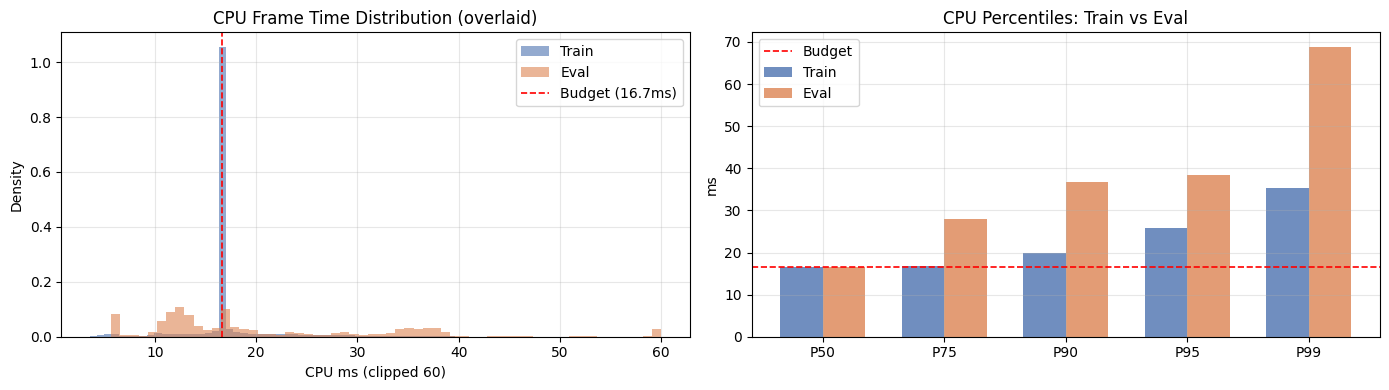

Saved compare_cpu_distribution.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train['cpu_ms'].clip(0, 60), bins=60, alpha=0.6, color=TC, label='Train', density=True)
axes[0].hist(eval_['cpu_ms'].clip(0, 60),  bins=60, alpha=0.6, color=EC, label='Eval',  density=True)
axes[0].axvline(TARGET_FRAME_MS, color='red', linestyle='--', linewidth=1.2, label=f'Budget ({TARGET_FRAME_MS:.1f}ms)')
axes[0].set_title('CPU Frame Time Distribution (overlaid)')
axes[0].set_xlabel('CPU ms (clipped 60)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# percentile bar chart
percentiles = [50, 75, 90, 95, 99]
tp = [train['cpu_ms'].quantile(p/100) for p in percentiles]
ep = [eval_['cpu_ms'].quantile(p/100)  for p in percentiles]
x  = np.arange(len(percentiles))
w  = 0.35
axes[1].bar(x - w/2, tp, w, label='Train', color=TC, alpha=0.8)
axes[1].bar(x + w/2, ep, w, label='Eval',  color=EC, alpha=0.8)
axes[1].axhline(TARGET_FRAME_MS, color='red', linestyle='--', linewidth=1.2, label='Budget')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'P{p}' for p in percentiles])
axes[1].set_title('CPU Percentiles: Train vs Eval')
axes[1].set_ylabel('ms')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'compare_cpu_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved compare_cpu_distribution.png')

## 6. Eval: LOD Bias and CPU Over Time

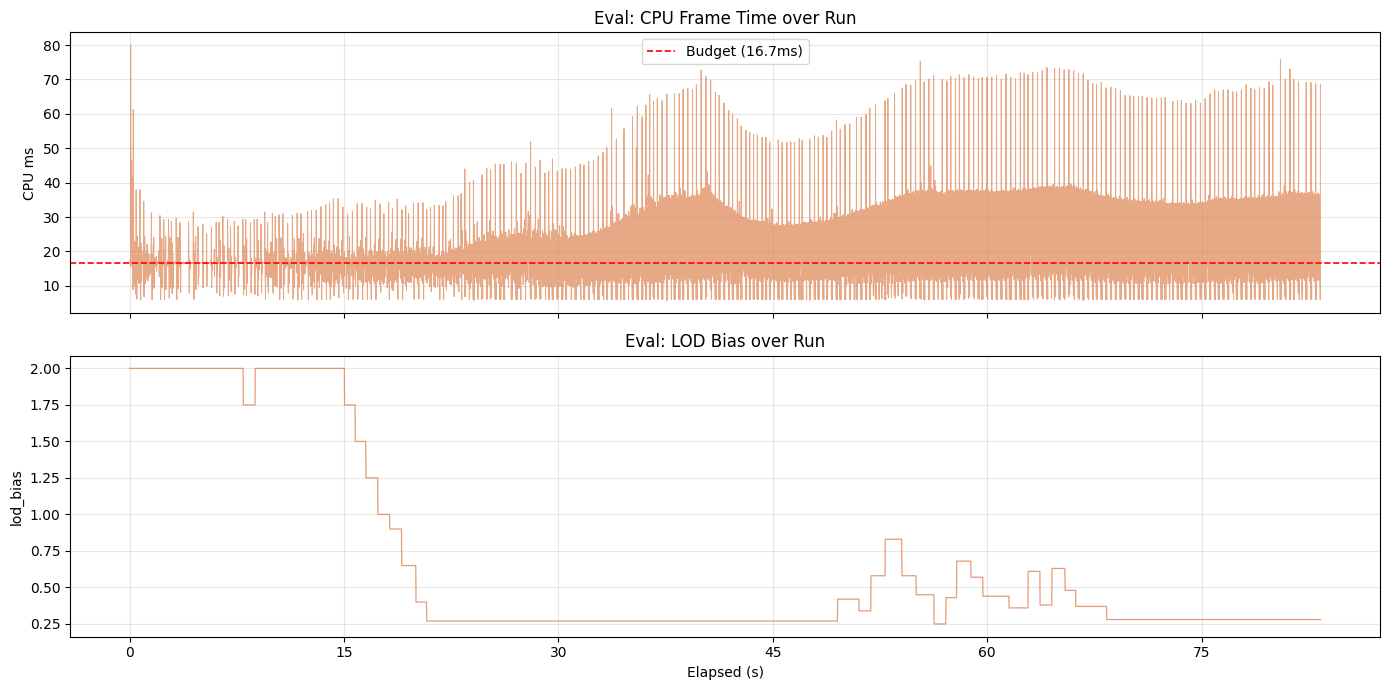

Saved compare_eval_over_time.png


In [39]:
es = eval_.sort_values('elapsed_s')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(es['elapsed_s'], es['cpu_ms'].clip(0, 80), color=EC, alpha=0.7, linewidth=0.7)
axes[0].axhline(TARGET_FRAME_MS, color='red', linestyle='--', linewidth=1.2, label=f'Budget ({TARGET_FRAME_MS:.1f}ms)')
axes[0].set_title('Eval: CPU Frame Time over Run')
axes[0].set_ylabel('CPU ms')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(es['elapsed_s'], es['lod_bias'], color=EC, alpha=0.8, linewidth=0.9)
axes[1].set_title('Eval: LOD Bias over Run')
axes[1].set_ylabel('lod_bias')
axes[1].set_xlabel('Elapsed (s)')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=8))

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'compare_eval_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved compare_eval_over_time.png')

## 7. LOD Bias vs CPU ms Scatter

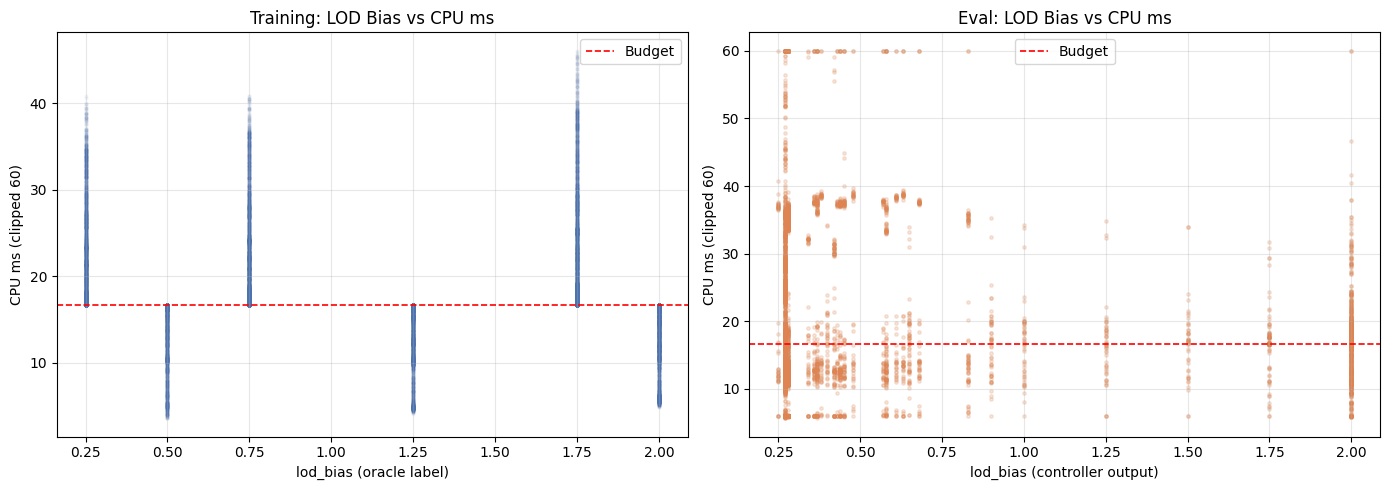

Saved compare_bias_vs_cpu_scatter.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train['lod_bias'], train['cpu_ms'].clip(0, 60),
                alpha=0.05, s=4, color=TC)
axes[0].axhline(TARGET_FRAME_MS, color='red', linestyle='--', linewidth=1.2, label='Budget')
axes[0].set_title('Training: LOD Bias vs CPU ms')
axes[0].set_xlabel('lod_bias (oracle label)')
axes[0].set_ylabel('CPU ms (clipped 60)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(eval_['lod_bias'], eval_['cpu_ms'].clip(0, 60),
                alpha=0.2, s=6, color=EC)
axes[1].axhline(TARGET_FRAME_MS, color='red', linestyle='--', linewidth=1.2, label='Budget')
axes[1].set_title('Eval: LOD Bias vs CPU ms')
axes[1].set_xlabel('lod_bias (controller output)')
axes[1].set_ylabel('CPU ms (clipped 60)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'compare_bias_vs_cpu_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved compare_bias_vs_cpu_scatter.png')

## 8. Path Progress Coverage

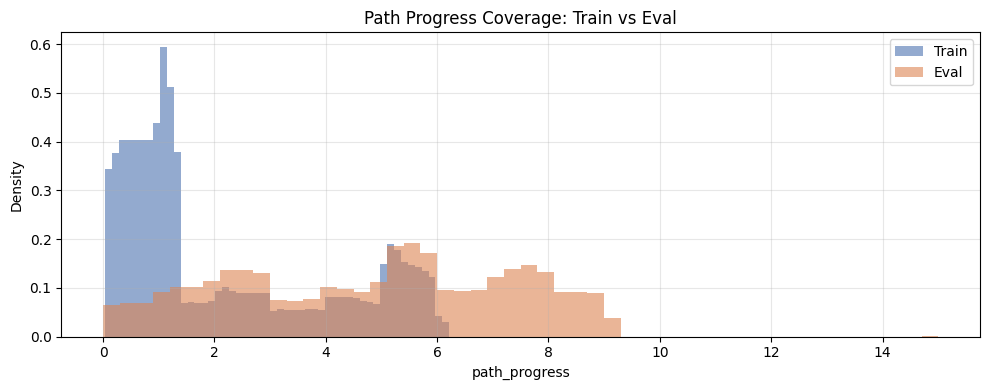

Saved compare_path_coverage.png


In [41]:
if 'path_progress' in train.columns and 'path_progress' in eval_.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(train['path_progress'], bins=50, alpha=0.6, color=TC, label='Train', density=True)
    ax.hist(eval_['path_progress'],  bins=50, alpha=0.6, color=EC, label='Eval',  density=True)
    ax.set_title('Path Progress Coverage: Train vs Eval')
    ax.set_xlabel('path_progress')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'compare_path_coverage.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved compare_path_coverage.png')
else:
    print('path_progress not available in both datasets — skipping')

## 9. GPU Frame Time Distribution

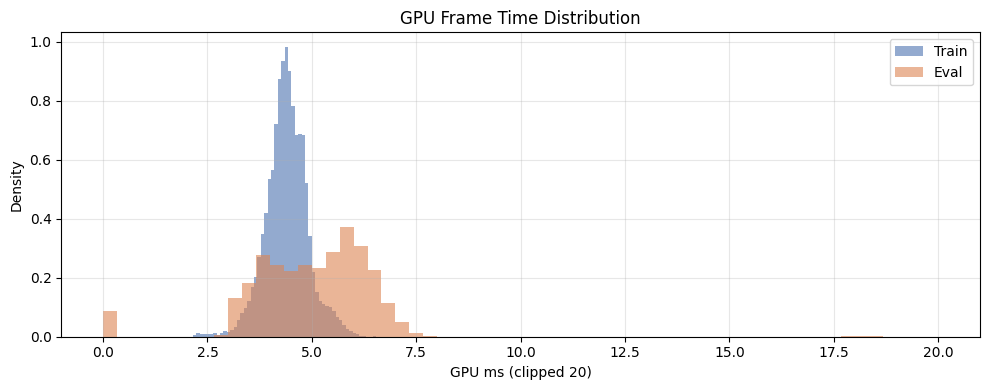

Saved compare_gpu_distribution.png


In [42]:
if 'gpu_ms' in train.columns and 'gpu_ms' in eval_.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(train['gpu_ms'].clip(0, 20), bins=60, alpha=0.6, color=TC, label='Train', density=True)
    ax.hist(eval_['gpu_ms'].clip(0, 20),  bins=60, alpha=0.6, color=EC, label='Eval',  density=True)
    ax.set_title('GPU Frame Time Distribution')
    ax.set_xlabel('GPU ms (clipped 20)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'compare_gpu_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved compare_gpu_distribution.png')
else:
    print('gpu_ms not available in both datasets — skipping')

## 10. Over-Budget Analysis per LOD Bias Level

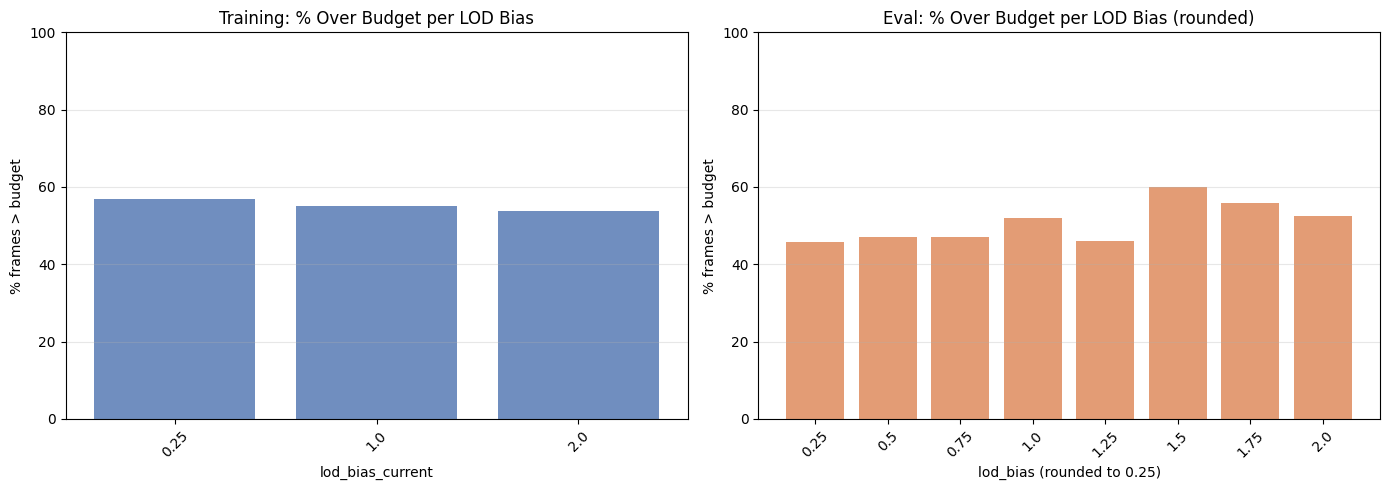

Saved compare_overbudget_per_bias.png


In [43]:
# training: use lod_bias_current if available, else lod_bias
train_bias_col = 'lod_bias_current' if 'lod_bias_current' in train.columns else 'lod_bias'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# training over-budget per bias
train_grp = train.groupby(train_bias_col)['over_budget'].mean() * 100
axes[0].bar(train_grp.index.astype(str), train_grp.values, color=TC, alpha=0.8)
axes[0].set_title('Training: % Over Budget per LOD Bias')
axes[0].set_xlabel('lod_bias_current')
axes[0].set_ylabel('% frames > budget')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# eval over-budget per bias (rounded to 0.25)
eval_bias_rounded = (eval_['lod_bias'] / 0.25).round() * 0.25
eval_grp = eval_.groupby(eval_bias_rounded)['over_budget'].mean() * 100
axes[1].bar(eval_grp.index.astype(str), eval_grp.values, color=EC, alpha=0.8)
axes[1].set_title('Eval: % Over Budget per LOD Bias (rounded)')
axes[1].set_xlabel('lod_bias (rounded to 0.25)')
axes[1].set_ylabel('% frames > budget')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'compare_overbudget_per_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved compare_overbudget_per_bias.png')